# **CLASSICAL TIME SERIES APPROACH**

**Ideas**
- SARIMA/SARIMAX
- Worth checking stationarity (ADF test) before committing to ARIMA specs
- Bridge Regression (i.e. final_production ≈ a + b × current_estimate(horizon))

It is worth keeping in mind that the USDA early projection numbers might run consistently high or low relative to final proj. numbers

Normal time series forecasting assumes you have a clean sequence of actual values and you're predicting the next one

These data are not like that.

For any given market year, the USDA published a sequence of guesses that evolve over roughly 18 months, starting rough and getting more accurate as the harvest data came in.

In [32]:
# Libraries
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
print(Path.cwd())

c:\Users\mason\OneDrive\Desktop\AgGenius\wasde_analysis\notebooks\models


In [5]:
PROJECT_ROOT = Path.cwd().parents[1]
df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'commodity_prod' / 'corn_prod.csv', index_col=0, parse_dates=True)

C:\Users\mason\AppData\Local\Temp\ipykernel_14316\2190123148.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'commodity_prod' / 'corn_prod.csv', index_col=0, parse_dates=True)


In [6]:
df.head()

,ReportDate,ReportTitle,Attribute,ReliabilityProjection,Commodity,Region,MarketYear,ProjEstFlag,AnnualQuarterFlag,Value,Unit,ReleaseDate,ReleaseTime,ForecastYear,ForecastMonth
WasdeNumber,,,,,,,,,,,,,,,
481,April 2010,U.S. Feed Grain and Corn Supply and Use,Production,NaN,Corn,United States,2007/08,NaN,Annual,13038.0,Million Bushels,2010-04-09,08:30:00.0000000,2010,4
481,April 2010,U.S. Feed Grain and Corn Supply and Use,Production,NaN,Corn,United States,2008/09,Est.,Annual,12092.0,Million Bushels,2010-04-09,08:30:00.0000000,2010,4
481,April 2010,U.S. Feed Grain and Corn Supply and Use,Production,NaN,Corn,United States,2009/10,Proj.,Annual,13131.0,Million Bushels,2010-04-09,08:30:00.0000000,2010,4
482,May 2010,U.S. Feed Grain and Corn Supply and Use,Production,NaN,Corn,United States,2008/09,NaN,Annual,12092.0,Million Bushels,2010-05-11,08:30:00.0000000,2010,5
482,May 2010,U.S. Feed Grain and Corn Supply and Use,Production,NaN,Corn,United States,2009/10,Est.,Annual,13110.0,Million Bushels,2010-05-11,08:30:00.0000000,2010,5


In [8]:
df.shape

(567, 15)

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 567 entries, 481 to 670
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ReportDate             567 non-null    str    
 1   ReportTitle            567 non-null    str    
 2   Attribute              567 non-null    str    
 3   ReliabilityProjection  0 non-null      float64
 4   Commodity              567 non-null    str    
 5   Region                 567 non-null    str    
 6   MarketYear             567 non-null    str    
 7   ProjEstFlag            378 non-null    str    
 8   AnnualQuarterFlag      567 non-null    str    
 9   Value                  567 non-null    float64
 10  Unit                   567 non-null    str    
 11  ReleaseDate            567 non-null    str    
 12  ReleaseTime            567 non-null    str    
 13  ForecastYear           567 non-null    int64  
 14  ForecastMonth          567 non-null    int64  
dtypes: float64(2), int64

In [11]:
df['ReportDate'] = pd.to_datetime(df['ReportDate'])
df = df.drop(columns='ReliabilityProjection')

df.info()

<class 'pandas.DataFrame'>
Index: 567 entries, 481 to 670
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ReportDate         567 non-null    datetime64[us]
 1   ReportTitle        567 non-null    str           
 2   Attribute          567 non-null    str           
 3   Commodity          567 non-null    str           
 4   Region             567 non-null    str           
 5   MarketYear         567 non-null    str           
 6   ProjEstFlag        378 non-null    str           
 7   AnnualQuarterFlag  567 non-null    str           
 8   Value              567 non-null    float64       
 9   Unit               567 non-null    str           
 10  ReleaseDate        567 non-null    str           
 11  ReleaseTime        567 non-null    str           
 12  ForecastYear       567 non-null    int64         
 13  ForecastMonth      567 non-null    int64         
dtypes: datetime64[us](1), fl

C:\Users\mason\AppData\Local\Temp\ipykernel_14316\3524604985.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ReportDate'] = pd.to_datetime(df['ReportDate'])


**Define Final Values**

In [12]:
finals = (
    df.sort_values('ReportDate')
      .groupby('MarketYear')
      .tail(1)
      .set_index('MarketYear')['Value']
      .rename('final_value')
)
print(finals)

MarketYear
2007/08    13038.0
2008/09    12092.0
2009/10    13092.0
2010/11    12447.0
2011/12    12360.0
2012/13    10755.0
2013/14    13829.0
2014/15    14216.0
2015/16    13602.0
2016/17    15148.0
2017/18    14609.0
2018/19    14340.0
2019/20    13620.0
2020/21    14111.0
2021/22    15018.0
2022/23    13651.0
2023/24    15341.0
2024/25    14892.0
2025/26    17021.0
Name: final_value, dtype: float64


A few sanity checks:
- 2012/13 (13,038 → 10,755) captures the major drought year
- 2023/24 hitting a record 15,341 lines up with what actually happened
- We'll need to exclude 2025/26 (and possibly 2024/25, depending on how "final" we want to be. The USDA typically keeps revising for a year or two after the marketing year ends) from training since we don't have ground truth to learn against yet.

In [18]:
# Get the date each market year was FIRST finalized (ProjEstFlag goes null)
# NOT the last time it appears in the dataset — finalized years keep reappearing
# as historical reference rows in every subsequent report, so .tail(1) on the
# full df was grabbing ~April 2026 for every year regardless of when it actually finalized.
finals_info = (
    df[df['ProjEstFlag'].isna()]
      .sort_values('ReportDate')
      .groupby('MarketYear')
      .head(1)
      .set_index('MarketYear')[['ReportDate', 'Value']]
      .rename(columns={'ReportDate': 'final_date', 'Value': 'final_value'})
)

# Keep only the "in-progress" estimates (rows where ProjEstFlag is still Est./Proj.)
# These are the real forecasts we're trying to bridge to the final number.
vintages = df[df['ProjEstFlag'].notna()].copy()

# Attach the final value and final date for that market year
vintages['final_value'] = vintages['MarketYear'].map(finals_info['final_value'])
vintages['final_date'] = vintages['MarketYear'].map(finals_info['final_date'])

# Horizon = how many months before finalization this estimate was made
vintages['horizon_months'] = (
    (vintages['final_date'].dt.year - vintages['ReportDate'].dt.year) * 12
    + (vintages['final_date'].dt.month - vintages['ReportDate'].dt.month)
)

# Drop the still-live 2025/26 year for now — no true final to train against yet
vintages = vintages[vintages['MarketYear'] != '2025/26']

vintages[['MarketYear', 'ReportDate', 'ProjEstFlag', 'Value', 'final_value', 'horizon_months']].sort_values(
    ['MarketYear', 'horizon_months']
)

,MarketYear,ReportDate,ProjEstFlag,Value,final_value,horizon_months
WasdeNumber,,,,,,
481,2008/09,2010-04-01,Est.,12092.0,12092.0,1.0
493,2009/10,2011-04-01,Est.,13092.0,13092.0,1.0
492,2009/10,2011-03-01,Est.,13092.0,13092.0,2.0
491,2009/10,2011-02-01,Est.,13092.0,13092.0,3.0
490,2009/10,2011-01-01,Est.,13092.0,13092.0,4.0
...,...,...,...,...,...,...
666,2024/25,2025-12-01,Est.,14892.0,NaN,NaN
667,2024/25,2026-01-01,Est.,14892.0,NaN,NaN
668,2024/25,2026-02-01,Est.,14892.0,NaN,NaN


How much data do we actually have per horizon?

In [19]:
vintages.groupby('horizon_months').size().sort_index()

horizon_months
1.0     16
2.0     15
3.0     15
4.0     14
5.0     15
6.0     15
7.0     13
8.0     15
9.0     15
10.0    15
11.0    15
12.0    15
13.0    15
14.0    14
15.0    14
16.0    13
17.0    14
18.0    14
19.0    12
20.0    14
21.0    14
22.0    14
23.0    14
24.0    14
dtype: int64

In [20]:
vintages.groupby('MarketYear')['horizon_months'].agg(['min', 'max', 'count'])

,min,max,count
MarketYear,,,
2008/09,1.0,1.0,1
2009/10,1.0,13.0,13
2010/11,1.0,24.0,24
2011/12,1.0,24.0,24
2012/13,1.0,24.0,23
2013/14,1.0,24.0,23
2014/15,1.0,24.0,24
2015/16,1.0,24.0,24
2016/17,1.0,24.0,24


**Bridge Regression**

final_value ≈ intercept + slope × current_estimate

In [25]:
results = {}

for h, group in vintages.groupby('horizon_months'):
    X = sm.add_constant(group['Value'])
    y = group['final_value']
    model = sm.OLS(y, X).fit()
    results[h] = {
        'n': len(group),
        'intercept': model.params['const'],
        'slope': model.params['Value'],
        'r_squared': model.rsquared
    }

bridge_summary = pd.DataFrame(results).T
bridge_summary.index.name = 'horizon_months'
print(bridge_summary)

                   n     intercept     slope  r_squared
horizon_months                                         
1.0             16.0  0.000000e+00  1.000000   1.000000
2.0             15.0  1.091394e-11  1.000000   1.000000
3.0             15.0  1.091394e-11  1.000000   1.000000
4.0             14.0  5.456968e-12  1.000000   1.000000
5.0             15.0  1.767265e+01  0.997505   0.999235
6.0             15.0  1.767265e+01  0.997505   0.999235
7.0             13.0  8.132530e+00  0.998031   0.998453
8.0             15.0  6.475967e+01  0.993483   0.999094
9.0             15.0  6.475967e+01  0.993483   0.999094
10.0            15.0  6.475967e+01  0.993483   0.999094
11.0            15.0  6.475967e+01  0.993483   0.999094
12.0            15.0  5.747894e+01  0.993790   0.999119
13.0            15.0  4.375969e+01  0.994546   0.999034
14.0            14.0  4.980720e+01  0.994166   0.999019
15.0            14.0  4.980720e+01  0.994166   0.999019
16.0            13.0  3.316595e+01  0.995628   0

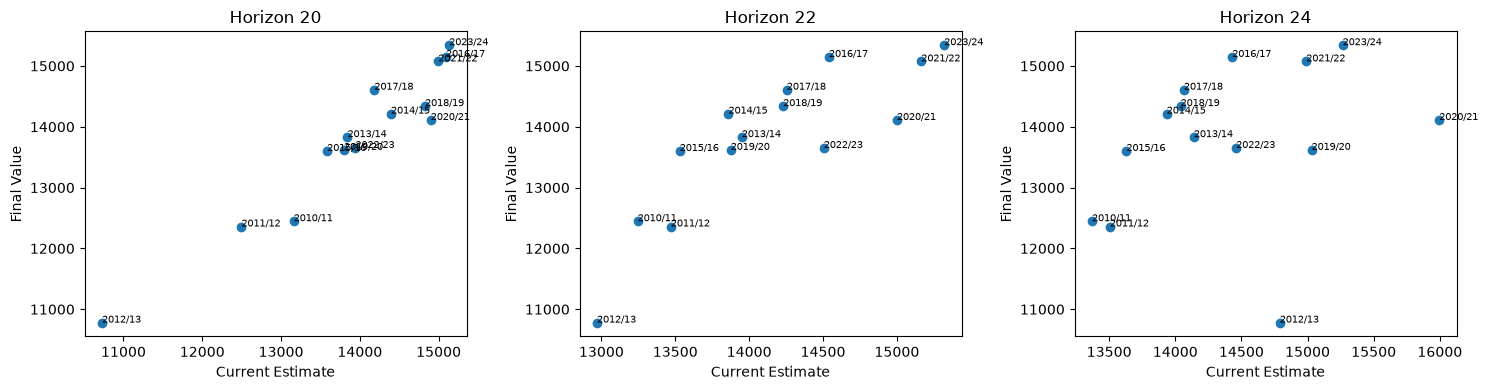

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, h in zip(axes, [20, 22, 24]):
    sub = vintages[vintages['horizon_months'] == h]
    ax.scatter(sub['Value'], sub['final_value'])
    for _, row in sub.iterrows():
        ax.annotate(row['MarketYear'], (row['Value'], row['final_value']), fontsize=7)
    ax.set_title(f'Horizon {h}')
    ax.set_xlabel('Current Estimate')
    ax.set_ylabel('Final Value')
plt.tight_layout()
plt.show()

<Axes: title={'center': 'R² by horizon'}, xlabel='horizon_months'>

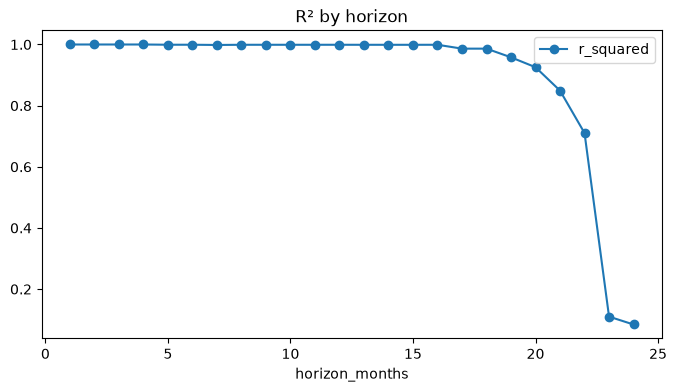

In [28]:
bridge_summary[['n', 'r_squared']].plot(y='r_squared', marker='o', figsize=(8,4), title='R² by horizon')

We should cut the reliable range at horizon 18 ish. R squared at 17-18 still strong. 19-21 are usable but with more uncertainty. 22+ essentially just noise.

# **REUSABLE PREDICTION FUNCTION**

In [29]:
def predict_final(current_estimate, horizon_months, bridge_summary,
                   caution_r2=0.85, min_reliable_r2=0.97, max_known_horizon=None):
    """
    Nowcast the final value for a market year given a live WASDE estimate.

    Parameters
    ----------
    current_estimate : float
        The current WASDE Value for this market year (Proj./Est.).
    horizon_months : int
        Months between this estimate's report and the year's expected finalization.
    bridge_summary : DataFrame
        Output from the per-horizon OLS fit (index=horizon_months,
        columns=['n', 'intercept', 'slope', 'r_squared']).
    caution_r2 : float
        Below this R², flag as low-confidence.
    min_reliable_r2 : float
        Above this R², flag as high-confidence.
    max_known_horizon : int, optional
        Horizons beyond this fall back to the raw estimate instead of a
        fitted correction. Defaults to bridge_summary's max index.

    Returns
    -------
    dict with keys: prediction, confidence, r_squared, horizon_used, note
    """
    if max_known_horizon is None:
        max_known_horizon = bridge_summary.index.max()

    # Beyond our fitted range entirely -> don't trust any slope/intercept,
    # just pass the raw estimate through with a clear low-confidence flag.
    if horizon_months > max_known_horizon:
        return {
            'prediction': current_estimate,
            'confidence': 'low',
            'r_squared': None,
            'horizon_used': None,
            'note': f'No fitted model beyond horizon {max_known_horizon}; returning raw estimate.'
        }

    # horizon_months might not have an exact match (e.g. horizon 0 was
    # excluded by construction) -- snap to the nearest available horizon.
    available_horizons = bridge_summary.index.to_numpy()
    horizon_used = available_horizons[np.argmin(np.abs(available_horizons - horizon_months))]

    row = bridge_summary.loc[horizon_used]
    prediction = row['intercept'] + row['slope'] * current_estimate
    r2 = row['r_squared']

    if r2 >= min_reliable_r2:
        confidence = 'high'
    elif r2 >= caution_r2:
        confidence = 'medium'
    else:
        confidence = 'low'

    return {
        'prediction': prediction,
        'confidence': confidence,
        'r_squared': r2,
        'horizon_used': int(horizon_used),
        'note': 'Snapped to nearest fitted horizon.' if horizon_used != horizon_months else None
    }

Test the function

In [30]:
recent = df[(df['MarketYear'] == '2025/26') & (df['ProjEstFlag'].notna())].sort_values('ReportDate')
print(recent[['ReportDate', 'Value']])

            ReportDate    Value
WasdeNumber                    
660         2025-05-01  15820.0
661         2025-06-01  15820.0
662         2025-07-01  15705.0
663         2025-08-01  16742.0
664         2025-09-01  16814.0
665         2025-11-01  16752.0
666         2025-12-01  16752.0
667         2026-01-01  17021.0
668         2026-02-01  17021.0
669         2026-03-01  17021.0
670         2026-04-01  17021.0


In [34]:
result = predict_final(
    current_estimate=17021,
    horizon_months=12,
    bridge_summary=bridge_summary
)
print(result)

{'prediction': np.float64(16972.783183771473), 'confidence': 'high', 'r_squared': np.float64(0.999118761791954), 'horizon_used': 12, 'note': None}


**Estimated-finalization-date Logic**

In [35]:
finals_check = finals_info.copy()
finals_check['final_month'] = finals_check['final_date'].dt.month
finals_check['final_year'] = finals_check['final_date'].dt.year

print(finals_check[['final_date', 'final_month', 'final_year']].sort_index())

           final_date  final_month  final_year
MarketYear                                    
2007/08    2010-04-01            4        2010
2008/09    2010-05-01            5        2010
2009/10    2011-05-01            5        2011
2010/11    2012-05-01            5        2012
2011/12    2013-05-01            5        2013
2012/13    2014-05-01            5        2014
2013/14    2015-05-01            5        2015
2014/15    2016-05-01            5        2016
2015/16    2017-05-01            5        2017
2016/17    2018-05-01            5        2018
2017/18    2019-05-01            5        2019
2018/19    2020-05-01            5        2020
2019/20    2021-05-01            5        2021
2020/21    2022-05-01            5        2022
2021/22    2023-05-01            5        2023
2022/23    2024-05-01            5        2024
2023/24    2025-05-01            5        2025


# **Finalization Date Estimator**

In [36]:
def estimate_final_date(market_year_str, final_month=5):
    """
    Estimate when a market year will finalize, based on the observed
    pattern: market year 'YYYY/YY+1' finalizes in May of the year after
    its second half (e.g., '2023/24' -> May 2025).
    """
    start_year = int(market_year_str.split('/')[0])
    second_half_year = start_year + 1
    estimated_final_year = second_half_year + 1
    return pd.Timestamp(year=estimated_final_year, month=final_month, day=1)

# Sanity check against known years -- should match finals_info almost exactly
for my in ['2022/23', '2023/24']:
    print(my, '->', estimate_final_date(my), '| actual:', finals_info.loc[my, 'final_date'])

2022/23 -> 2024-05-01 00:00:00 | actual: 2024-05-01 00:00:00
2023/24 -> 2025-05-01 00:00:00 | actual: 2025-05-01 00:00:00


In [37]:
est_final_2025_26 = estimate_final_date('2025/26')
print(est_final_2025_26)

2027-05-01 00:00:00


# **Nowcast the final value for 2025/26 based on the most recent WASDE estimate**

In [38]:
latest_report_date = pd.Timestamp('2026-04-01')
latest_value = 17021

real_horizon = (
    (est_final_2025_26.year - latest_report_date.year) * 12
    + (est_final_2025_26.month - latest_report_date.month)
)
print('Estimated horizon:', real_horizon)

result = predict_final(
    current_estimate=latest_value,
    horizon_months=real_horizon,
    bridge_summary=bridge_summary
)
print(result)

Estimated horizon: 13
{'prediction': np.float64(16971.918704795546), 'confidence': 'high', 'r_squared': np.float64(0.9990341775735867), 'horizon_used': 13, 'note': None}
